## Import all required libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, RocCurveDisplay)
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

## Convert House Prices to a classification problem

In [2]:
df = pd.read_csv('House_Price_prediction.csv')

# Engineer features from Day 6
df['House_Age']      = 2024 - df['YearBuilt']
df['Total_Rooms']    = df['Bedrooms'] + df['Bathrooms']
df['Is_New']         = (df['House_Age'] < 10).astype(int)
df['Is_MultiFloor']  = (df['Floors'] > 1).astype(int)

# CREATE TARGET: bin Price into 3 classes
df['Price_Tier'] = pd.cut(df['Price'],
                           bins=3,
                           labels=['Cheap','Mid','Expensive'])

print(df['Price_Tier'].value_counts())
# Check class balance — important before training

Price_Tier
Expensive    706
Mid          657
Cheap        637
Name: count, dtype: int64


## Encode and Prepare

In [3]:
# Encode target
le = LabelEncoder()
y  = le.fit_transform(df['Price_Tier'])  # Cheap=0, Expensive=1, Mid=2

# Only encode columns that are actually present in df
columns_to_encode = [col for col in ['Location', 'Condition', 'Garage'] if col in df.columns]

if columns_to_encode:
    df = pd.get_dummies(df, columns=columns_to_encode, drop_first=True)
# Encode categoricals
#df = pd.get_dummies(df, columns=['Location','Condition','Garage'],
                   # drop_first=True)
drop_cols = ['Price','Price_Tier','YearBuilt']
df = df.drop(columns=drop_cols, errors='ignore')

X = df.values

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
# stratify=y → keeps class distribution same in both splits

# Scale
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

## Train Logistic Regression

In [4]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr,
                             target_names=le.classes_))
# Shows precision, recall, F1 for each class

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
print("\nConfusion Matrix:\n", cm)

=== Logistic Regression ===
              precision    recall  f1-score   support

       Cheap       0.34      0.30      0.32       128
   Expensive       0.36      0.50      0.42       141
         Mid       0.32      0.23      0.27       131

    accuracy                           0.34       400
   macro avg       0.34      0.34      0.33       400
weighted avg       0.34      0.34      0.34       400


Confusion Matrix:
 [[38 63 27]
 [35 70 36]
 [38 63 30]]


## Train Decision Tree

In [5]:
# Without depth limit — likely overfits
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train_sc, y_train)

# With depth limit — controls overfitting
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_sc, y_train)
y_pred_dt = dt.predict(X_test_sc)

print("=== Decision Tree (max_depth=5) ===")
print(classification_report(y_test, y_pred_dt,
                             target_names=le.classes_))

# Compare train vs test accuracy to detect overfitting
print(f"\nFull tree  — Train: {dt_full.score(X_train_sc,y_train):.3f}  Test: {dt_full.score(X_test_sc,y_test):.3f}")
print(f"Pruned tree — Train: {dt.score(X_train_sc,y_train):.3f}  Test: {dt.score(X_test_sc,y_test):.3f}")
# Full:   Train 1.000, Test 0.720  → massive overfit
# Pruned: Train 0.850, Test 0.810  → much better generalization

=== Decision Tree (max_depth=5) ===
              precision    recall  f1-score   support

       Cheap       0.10      0.02      0.03       128
   Expensive       0.35      0.91      0.50       141
         Mid       0.43      0.02      0.04       131

    accuracy                           0.34       400
   macro avg       0.29      0.32      0.19       400
weighted avg       0.29      0.34      0.20       400


Full tree  — Train: 1.000  Test: 0.315
Pruned tree — Train: 0.391  Test: 0.335


## Visualize Confusion Matrix and ROC

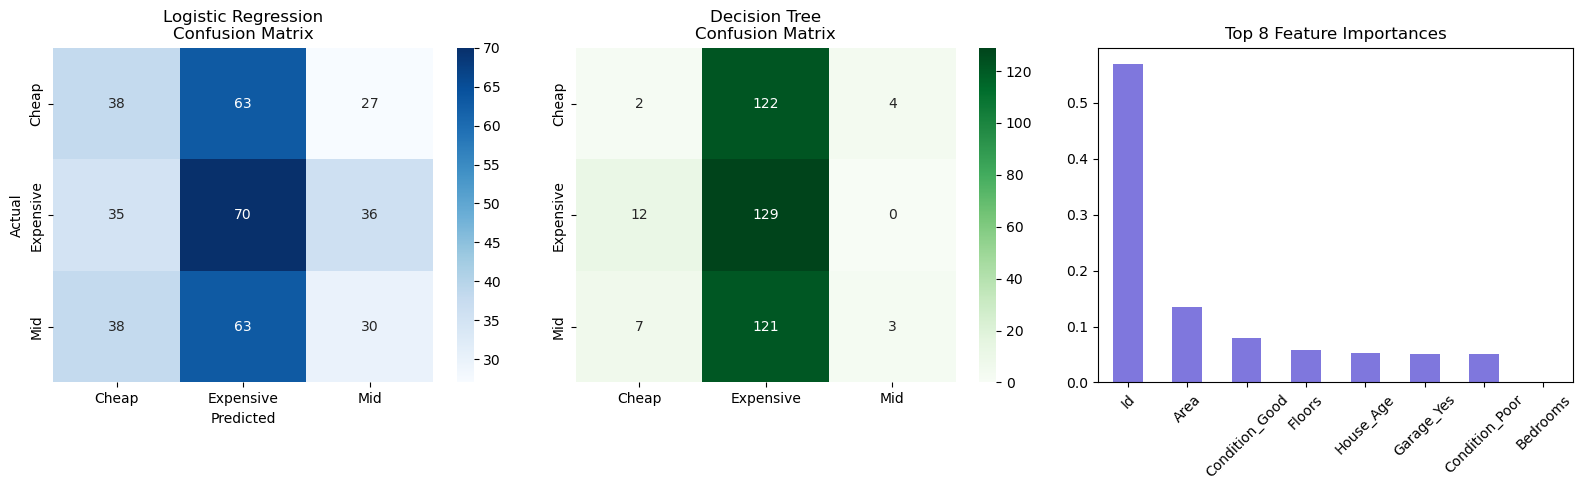

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion matrix — Logistic Regression
import seaborn as sns
sns.heatmap(confusion_matrix(y_test, y_pred_lr),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Logistic Regression\nConfusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Confusion matrix — Decision Tree
sns.heatmap(confusion_matrix(y_test, y_pred_dt),
            annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_,
            yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Decision Tree\nConfusion Matrix')

# Feature importances from Decision Tree
importances = pd.Series(dt.feature_importances_,
                         index=df.columns).sort_values(ascending=False)[:8]
importances.plot(kind='bar', ax=axes[2], color='#7F77DD')
axes[2].set_title('Top 8 Feature Importances')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Model Comparison

In [7]:
from sklearn.metrics import f1_score, accuracy_score

models = {
    'Logistic Regression': y_pred_lr,
    'Decision Tree':       y_pred_dt
}

print(f"\n{'Model':<25} {'Accuracy':>10} {'F1 (macro)':>12}")
print("─" * 50)
for name, preds in models.items():
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='macro')
    print(f"{name:<25} {acc:>10.3f} {f1:>12.3f}")


Model                       Accuracy   F1 (macro)
──────────────────────────────────────────────────
Logistic Regression            0.345        0.334
Decision Tree                  0.335        0.191
